In [1]:
# specify to reload any packages that are changed
# helps with not having to restart the kernel each time
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import sys
import copy
import corner
import h5py
print(sys.executable)
sys.path.insert(0,'/home/cw1074/scarlet_uptodate/scarlet2')
sys.path.insert(0,'/home/cw1074/HSC/pulsars/scarlet')
import os
import scarlet
print(scarlet.__file__)
import astropy.io.fits as fits
from astropy.wcs import WCS
from scarlet.display import AsinhMapping,AsinhPercentileNorm,show_scarlet2_scene,LinearPercentileNorm
import glob
import sep
import tarfile
import matplotlib
import matplotlib.pyplot as plt
import numpyro.distributions as dist
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.wcs import WCS
from scarlet.source import StaticSource,MultiExtendedSource, StaticMultiExtendedSource
import jax.numpy as jnp
import equinox as eqx
from jax import random, jit
import distrax
import optax
from tqdm.auto import tqdm
import pandas as pd
from numpyro.distributions import constraints
import cmasher as cmr
from scarlet2 import *
import scarlet2
from scarlet2 import relative_step
print(scarlet2.__file__)
# use a better colormap and don't interpolate the pixels
matplotlib.rc('image', cmap='gray', interpolation='none', origin='lower')
from matplotlib.patches import Ellipse
from scipy.stats import gaussian_kde as kde
from scipy.stats import norm
from functools import partial
from skimage import draw
%matplotlib inline
import astrophot as ap
pixelscale=0.17
from astropy.wcs import WCS

/home/cw1074/.conda/envs/scarlet/bin/python
/home/cw1074/HSC/pulsars/scarlet/scarlet/__init__.py


/home/cw1074/.conda/envs/scarlet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


/home/cw1074/scarlet_uptodate/scarlet2/scarlet2/__init__.py


In [3]:
def set_plot_style(doit=True,serif=True,use_tex=True):
    # NB -- for this to work
    # sudo apt install texlive-latex-base
    # sudo apt install msttcorefonts -qq
    # sudo apt-get install dvipng texlive-latex-extra texlive-fonts-recommended cm-super
    # rm ~/.cache/matplotlib -rf
    from matplotlib import cycler
    new_rcparams = {
        # Set color cycle: blue, green, yellow, red, violet, gray
        #'#axes.prop_cycle' : cycler('color', ['0C5DA5', '00B945', 'FF9500', 'FF2C00', '845B97', '474747', '9e9e9e']),
        # Set color cycle: blue, orange, green, red, violet, gray
        'axes.prop_cycle' : cycler('color', ['0C5DA5', 'FF9500', '00B945', 'FF2C00', '845B97', '474747', '9e9e9e']),
        # Set default figure size
        'figure.figsize' : (4*1.5, 3*1.5),
        # Set x axis
        'xtick.direction' : 'in',
        'xtick.major.size' : 3*2,
        'xtick.major.width' : 0.5,
        'xtick.minor.size' : 1.5*2,
        'xtick.minor.width' : 0.5,
        'xtick.minor.visible' : True,
        'xtick.top' : True,
        # Set y axis
        'ytick.direction' : 'in',
        'ytick.major.size' : 3*2,
        'ytick.major.width' : 0.5,
        'ytick.minor.size' : 1.5*2,
        'ytick.minor.width' : 0.5,
        'ytick.minor.visible' : True,
        'ytick.right' : True,
        # Set line widths
        'axes.linewidth' : 0.5,
        'grid.linewidth' : 0.5,
        'lines.linewidth' : 1.,
        # Remove legend' frame
        'legend.frameon' : False,
        # Always save as 'tight'
        'savefig.bbox' : 'tight',
        'savefig.pad_inches' : 0.05,
    }
    if use_tex:
        new_rcparams.update({
            # Use LaTeX for math formatting
            'text.usetex' : True,
            'text.latex.preamble' : r'\usepackage{amsmath}'
            })
    if serif:
        new_rcparams.update({
            # Use serif fonts
            'font.serif' : 'Times New Roman',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
            'legend.fontsize' : 'large',
            'xtick.labelsize' : 'x-large',
            'ytick.labelsize' : 'x-large',
            'axes.labelsize' : 'xx-large',
            })
    if doit:
        plt.rcParams.update(new_rcparams)
    else:
        return new_rcparams
set_plot_style()
plt.rcParams["font.family"] = "Serif"

In [4]:
data_path = '/scratch/gpfs/cw1074/SNsims_TD_noise'

channels_all = []
bandall = ['g','r','i','G','R','I']
channels_hsc = ['g','r','i']
channels_hst = ['G','R','I']
channels_zeroed = []

#This is where you need to define which images to read in
imgindex=8771#1568
plotdir=data_path+'/'+"image_LSST_"+str(imgindex)
if not os.path.exists(plotdir):
    os.mkdir(plotdir)
# Load the HSC image data
data_hsc=[]
ton= 56200 #This is where I define the mjd of the high resolution image - I choose one where the supernova is 'on' so it helps us constrain the point source positions
toff=56348
mjdstart=56000
observations=[]
psf_hsc_data  = fits.open("/home/cw1074/ZTF/lensing/psf_LSST.fits")[0].data.astype('float32')           
Np1, Np2 = psf_hsc_data.shape
psf_hsc_ = jnp.asarray([psf_hsc_data,psf_hsc_data,psf_hsc_data])
psf_hsc = scarlet2.ArrayPSF(psf_hsc_)
times=[]   


#Read in all epochs of low resolution images
for band in channels_hsc:
    imgs = glob.glob(data_path+'/'+"image_LSST_"+band[-1]+"_"+str(imgindex)+"_newSN*.fits")
    for ind,img in enumerate(imgs[:20]):
        timeimg = img.rstrip('.fits').split('_newSN')[-1]
        times.append(timeimg)
        channel_sc2 = (band, str(ind))   
        if float(timeimg)>mjdstart and float(timeimg)<mjdstart+400:
            channels_zeroed.append(channel_sc2)
        obs_hdu = fits.open(img)
        data_hsc = obs_hdu[0].data
        N1, N2 = data_hsc.shape
        data_hsc = data_hsc.reshape(1, N1, N2)
        obs_hduw = fits.open(os.path.join(data_path, "image_LSST_"+band[-1]+"_wcs_"+str(imgindex)+"_newSN"+timeimg+".fits"))
        wcs_hsc = WCS(obs_hduw[0].header)
        data_hsc = jnp.array(np.asfarray(data_hsc).byteswap().newbyteorder(), jnp.float32)  
        obs_hsc = scarlet2.Observation(data_hsc,
                                      wcs=wcs_hsc,
                                      psf=psf_hsc,
                                      channels=[channel_sc2],
                                      weights=None)
        channels_all.append(channel_sc2)
        observations.append(obs_hsc)

psf_hst = fits.open("/home/cw1074/ZTF/lensing/psf_Roman.fits")[0].data
psf_hst = jnp.array(psf_hst, jnp.float32)
psf_hst_ = jnp.asarray([psf_hst,psf_hst,psf_hst])
psf_hst_ = (psf_hst_-np.min(psf_hst_))/(np.max(psf_hst_)-np.min(psf_hst_))
psf_hst = scarlet2.ArrayPSF(psf_hst_)

#Read in a single epoch of high resolution imaging without the SN
for b,band in zip(['g','r','i'],channels_hst):
    # Load the HST image data
    hst_hdu = fits.open(os.path.join(data_path, "image_Roman_"+b+"_"+str(imgindex)+"_newSN"+str(toff)+".fits"))
    data_hst = hst_hdu[0].data
    N1, N2 = data_hst.shape
    data_hst = data_hst.reshape(1, N1, N2)
    hst_hdu = fits.open(os.path.join(data_path, "image_Roman_"+b+"_wcs_"+str(imgindex)+"_newSN"+str(toff)+".fits"))
    wcs_hst = WCS(hst_hdu[0].header)
    channel_sc2 = (band, '0')#str(ind))   
    #if float(timeimg)>mjdstart and float(timeimg)<mjdstart+400:
    #    channels_zeroed.append(channel_sc2)
    data_hst_preSN = jnp.array(np.asfarray(data_hst).byteswap().newbyteorder(), jnp.float32)
    # Scale the HST data
    n,n1, n2 = jnp.shape(data_hst)
    #data_hst *= data_hsc.max() / data_hst.max()
    
    N,N1, N2 = data_hsc.shape
    # define two observation packages and match to frame
    obs_hst_preSN = scarlet2.Observation(data_hst,
                                   wcs=wcs_hst,
                                   psf=psf_hst,
                                   channels=[channel_sc2],
                                   weights=None)
    
    channels_all.append(channel_sc2)
    observations.append(obs_hst_preSN)

#Read in a single epoch of high resolution imaging with the SN
for b,band in zip(['g','r','i'],channels_hst):
    # Load the HST image data
    hst_hdu = fits.open(os.path.join(data_path, "image_Roman_"+b+"_"+str(imgindex)+"_newSN"+str(ton)+".fits"))
    data_hst = hst_hdu[0].data
    N1, N2 = data_hst.shape
    data_hst = data_hst.reshape(1, N1, N2)
       
    wcs_hst = WCS(hst_hdu[0].header)
    print(wcs_hst)
    data_hst = jnp.array(np.asfarray(data_hst).byteswap().newbyteorder(), jnp.float32)
    # Load the HST PSF data
    channel_sc2 = (band, '1')   
    if float(timeimg)>mjdstart and float(timeimg)<mjdstart+400:
        channels_zeroed.append(channel_sc2)

    # define two observation packages and match to frame
    obs_hst = scarlet2.Observation(data_hst,
                                   wcs=wcs_hst,
                                   psf=psf_hst,
                                   channels=[channel_sc2],
                                   weights=None)
    channels_all.append(channel_sc2)
    observations.append(obs_hst)
    
#How many observations did we end up reading in? Should be at least a few
print(len(observations))

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 0.0  0.0  
CRPIX : 2.0  28.0  
CD1_1 CD1_2  : -3.0555555555555e-05  -0.0  
CD2_1 CD2_2  : 0.0  3.05555555555555e-05  
NAXIS : 55  55
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 0.0  0.0  
CRPIX : 2.0  28.0  
CD1_1 CD1_2  : -3.0555555555555e-05  -0.0  
CD2_1 CD2_2  : 0.0  3.05555555555555e-05  
NAXIS : 55  55
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 0.0  0.0  
CRPIX : 2.0  28.0  
CD1_1 CD1_2  : -3.0555555555555e-05  -0.0  
CD2_1 CD2_2  : 0.0  3.05555555555555e-05  
NAXIS : 55  55
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 0.0  0.0  
CRPIX : 2.0  28.0  
CD1_1 CD1_2  : -3.0555555555555e-05  -0.0  
CD2_1 CD2_2  : 0.0  3.05555555555555e-05  
NAXIS : 55  55
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 0.0  0.0  
CRPIX : 2.0  28.0  
CD1_1 CD1_2  : -3.0555555555555e-05  -0.0  
CD2_1 CD

In [5]:
frame_psf = scarlet2.GaussianPSF(0.7)
frameall = scarlet2.Frame.from_observations(observations,model_psf=frame_psf,model_wcs=wcs_hst)
for obs in observations:
    obs.match(frameall)
    

/home/cw1074/scarlet_uptodate/scarlet2/scarlet2/frame.py:225: UserWarning: Explicitly requested dtype int requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  y_min = jnp.floor(jnp.min(obs_coord[:, 0])).astype("int")
/home/cw1074/scarlet_uptodate/scarlet2/scarlet2/frame.py:226: UserWarning: Explicitly requested dtype int requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  x_min = jnp.floor(jnp.min(obs_coord[:, 1])).astype("int")
/home/cw1074/scarlet_uptodate/scarlet2/scarlet2/frame.py:227: UserWarning: Explicitly requested dtype int requested in astype is not available, and will be trunca

Provide name and position of source, desired bands, and location of image data.

Define a function which stacks the images and performs source detection on the stack

In [6]:
def makeCatalog(observations, lvl=3, wave=True,SNR=2.0):
    
    normed_images = np.asarray([obs.data[0] for obs in observations])
    interps = normed_images
    
    interps = np.asarray(interps/np.sum(interps))
    detect_image = np.sum(interps,axis=(0))
    # Wavelet transform
    wave_detect = scarlet.Starlet.from_image(detect_image).coefficients

    if wave:
        # Creates detection from the first 3 wavelet levels
        detect = wave_detect[:lvl,:,:].sum(axis = 0)
    else:
        detect = detect_image

        # Runs SEP detection
    bkg = sep.Background(detect)
    catalog = sep.extract(detect-bkg.globalback, SNR, err=bkg.globalrms)
    background=[]
    bg_rms=[]
    for ind in range(len(observations)):
        img = np.asfarray(observations[ind].data)
        if np.size(img.shape) == 3:
            bg_rms.append(np.array([sep.Background(band).globalrms for band in img]))
            background.append(np.array([sep.Background(band).globalback for band in img]))
        else:
            bg_rms.append(sep.Background(img).globalrms)
            background.append(sep.Background(img).globalback)
    return catalog, bg_rms, detect_image, background

Run source detection to create a catalog of source positions. Subtract background from images.

In [7]:
#If the source detection is not finding all the sources, you can first try to adjust these three parameters to help it find the sources
lvl=1
wave=2
SNR=2.0
catalog_single, bgsingle, detectsingle, globalback = makeCatalog(observations[:-6], lvl, wave,SNR=SNR)
obssinglearr=np.asarray(observations)
bgarr=np.asfarray(bgsingle)
observations_sc2=[]
normsingle=[]

for ind,(obs2,bg,back) in enumerate(zip(observations[:-6],bgarr,globalback)):
    w = obs2.frame.wcs
    weights2=np.ones(obs2.data.shape) / (10**bgarr**2)[:, None, None]
    #Subtract background flux
    data = obs2.data-back
    obs_sc2 = scarlet2.Observation(jnp.asarray(data), jnp.asarray(weights2), psf=psf_hsc,channels=[channels_all[ind]],wcs=w)
    observations_sc2.append(obs_sc2)
    #Store norm based on observation data
    normsingle.append(AsinhPercentileNorm(obs.data[:,10:-10,10:-10],percentiles=[0.001, 80]))

catalog_single, bgsingle, detectsingle, globalback = makeCatalog(observations[-6:], lvl, wave)
obssinglearr=np.asarray(observations)

bgarrall=np.hstack((bgarr.flatten(),np.asfarray(bgsingle).flatten()))
print(bgarrall.shape)
bgarr=np.asfarray(bgsingle)
pixel = np.stack((catalog_single['y'], catalog_single['x']), axis=1)
ra_dec = pixel

normsingle=[]
for ind,(obs2,bg,back) in enumerate(zip(observations[-6:],bgarr,globalback)):
    w = obs2.frame.wcs
    weights2=np.ones(obs2.data.shape) / (10*bgarr**2)[:, None, None]
    #Subtract background flux
    data = obs2.data-back
    obs_sc2 = scarlet2.Observation(jnp.asarray(data), jnp.asarray(weights2), psf=psf_hsc,channels=[channels_all[ind]],wcs=w)
    observations_sc2.append(obs_sc2)
    #Store norm based on observation data
    normsingle.append(AsinhPercentileNorm(obs.data[:,10:-10,10:-10],percentiles=[0.001, 80]))
pixel = np.stack((catalog_single['y'], catalog_single['x']), axis=1)
print(ra_dec.shape)

for obs in observations_sc2:
    obs.match(frameall)

66 60 60
(66,)
[[23.64906427 27.10612103]
 [25.74176598 24.33806833]
 [27.50209885 28.81650441]
 [30.65548613 25.01931248]
 [44.000571   33.98178738]]


Plot the first couple of images

Initialize scarlet to match up images to corresponding bands

Create the blend and plot the initial guess for the first two images

Define the scarlet2 PSF model and model frame. Match the model frame to the observations.

66


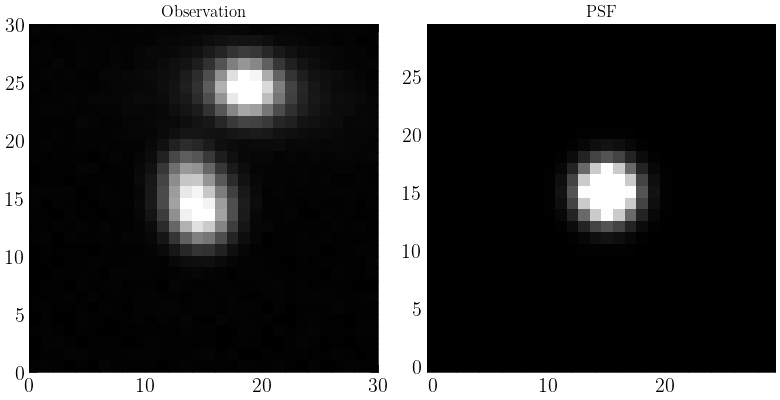

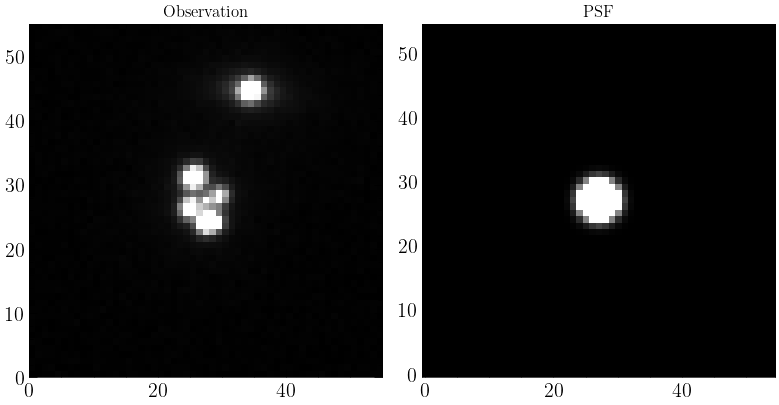

In [8]:
print(len(observations_sc2))
scarlet2.plot.observation(
    observation=observations_sc2[0],
    norm=None,#normsingle[0],
    channel_map=None,
    show_psf=True,
    add_labels=False,
)
plt.show()
scarlet2.plot.observation(
    observation=observations_sc2[-1],
    norm=None,#normsingle[0],
    channel_map=None,
    show_psf=True,
    add_labels=False,
)
plt.show()


In [9]:
centercoord = SkyCoord(30.0*u.deg,30.0*u.deg,frame='icrs')
if np.asarray(ra_dec).shape==(2,):
    separ=[0]
    indtransient=0
else:
    c2 = [SkyCoord(ra*u.deg,dec*u.deg,frame='icrs') for ra,dec in ra_dec]
    separ = [centercoord.separation(c).arcsecond for c in c2]
    indtransient = np.argmin(separ)
print(indtransient)

2


In [10]:

from galaxygrad import HSC_ScoreNet32, ZTF_ScoreNet64,LSST_ScoreNet60, ROMAN_ScoreNet120
stepnum=3000

from scarlet2 import nn

priorlens = nn.ScorePrior(
            model=ZTF_ScoreNet64
        )
priorhost = nn.ScorePrior(
            model=ROMAN_ScoreNet120
        )

Nimages = len(observations_sc2)
with scarlet2.Scene(frameall) as scene:
    #Initialize the lens in the center
    N_hst = observations_sc2[-1].data.shape[-1]
    N_hsc = observations_sc2[0].data.shape[-1]
    coord = wcs_hst.pixel_to_world(N_hst/2,N_hst/2)
    center_hst = jnp.asarray(np.asarray([int(N_hst/2),int(N_hst/2)]))
    center_hsc = jnp.asarray(np.asarray([int(N_hsc/2),int(N_hsc/2)]))
    try:
        flux,morph_init = initialization.from_gaussian_moments(observations_sc2[-1], center_hst,min_snr=5.0,min_corr=3.0,min_size=13)# + 1e-12           
    except ValueError:   
        flux = initialization.pixel_spectrum(observations_sc2[-1], center_hst, return_array=True)#center, return_array=True)
        print(flux)
        morph_init = np.pad(obs_hsc.frame.psf()[0]-np.min(obs_hsc.frame.psf()),(0, 0), 'constant')
        morph_init = morph_init/np.sum(morph_init)+1e-12
        morph_init = scarlet2.ArrayMorphology(jnp.asarray(morph_init))
 
    flux_hst = np.copy(initialization.pixel_spectrum(observations_sc2[-3:], center_hst, return_array=True))
    flux_hst[flux_hst<1e-6]=1e-1
    flux_hsc = np.copy(initialization.pixel_spectrum(observations_sc2[:3], center_hsc, return_array=True))
    flux_hsc[flux_hsc<1e-6]=1e-1
    flux = np.hstack((flux_hsc[:3],flux_hst[-3:]))
    scarlet2.Source(
        coord,
        #scarlet2.ArraySpectrum(jnp.asarray(flux)),
        scarlet2.StaticArraySpectrum(jnp.asarray(flux),filters=bandall),
        morph_init)
    '''
    flux = np.copy(np.asarray(initialization.pixel_spectrum(obs_hst, np.asarray([28,28]),return_array=True)))
    
    flux = np.hstack((flux,0.03*flux))#,flux,0.03*flux))
    print('ring flux',flux)
    flux[flux<1e-6]=1e-6
    
    morph_init = initialization.ring_morphology(6.0,2.0,30,return_array=True)
    
    morph=StarletMorphology.from_image(morph_init)
    scarlet2.Source(
        coord,
        #scarlet2.ArraySpectrum(jnp.asarray(flux)),
        StaticArraySpectrum(jnp.asarray(flux),filters=bandall),
        #scarlet2.ArrayMorphology(morph_init))
        scarlet2.ArrayMorphology(morph()))
    '''
    for i,pos in enumerate(ra_dec):     
        coord = wcs_hst.pixel_to_world(pos[1],pos[0])
        center = jnp.asarray(np.asfarray([pos[1],pos[0]]))
        #This index needs to be changed to whatever source number is given to the lensed host galaxy, which should be modeled as an extended source
        if i==4:
            try:
                flux,morph_init = initialization.from_gaussian_moments(observations_sc2[-1], center_hst,min_snr=5.0,min_corr=3.0,min_size=13)# + 1e-12           
            except ValueError:
            
                flux = initialization.pixel_spectrum(observations_sc2[-1], center_hst, return_array=True)#center, return_array=True)
                print(flux)
                morph_init = np.pad(obs_hsc.frame.psf()[0]-np.min(obs_hsc.frame.psf()),(0, 0), 'constant')
                morph_init = morph_init/np.sum(morph_init)+1e-12
        
                morph_init = scarlet2.ArrayMorphology(jnp.asarray(morph_init))
         
            flux_hst = initialization.pixel_spectrum(observations_sc2[-6:], np.asarray(center_hst), return_array=True)#
            flux_hsc = initialization.pixel_spectrum(observations_sc2[:-6], np.asarray(center_hsc), return_array=True)#
            flux_static = np.hstack((flux_hsc[:3],flux_hst[-3:]))
            flux_static[flux_static<1e-6]=1e-1
            scarlet2.Source(
                coord,
                scarlet2.StaticArraySpectrum(jnp.asarray(flux_static),filters=bandall),
                morph_init)
            
        else:
            flux_hst = initialization.pixel_spectrum(observations_sc2, np.asarray(center_hst), return_array=True)#
            flux_hsc = initialization.pixel_spectrum(observations_sc2, np.asarray(center_hsc), return_array=True)#
            flux_var = np.hstack((flux_hsc[:-6],flux_hst[-6:]))
            flux_var[flux_var<1e-6]=1e-6
            flux_var[np.isnan(flux_var)]=1e-6
            scarlet2.PointSource(
                    coord,
                    scarlet2.TransientArraySpectrum(jnp.asarray(flux_var),epochs = channels_zeroed))
                
indtransient=0       

step = lambda p: scarlet2.relative_step(p, factor=1e-3)
stepbig = lambda p: scarlet2.relative_step(p, factor=1e-3)
parameters = scene.make_parameters()
for i in range(len(scene.sources)):
    #Initialize point sources with a spectrum and a center
    if i<5 and i>0:
        print(scene.sources[i].spectrum.data)
        parameters += Parameter(scene.sources[i].spectrum.data, name=f"spectrum.{i}", constraint=constraints.positive, stepsize=stepbig)
        parameters += Parameter(scene.sources[i].center, name=f"morph.center.{i}", constraint=constraints.positive, stepsize=1e-2)
    else: #Initalize extended sources with a spectrum and a shape
        print('Init1')
        parameters += Parameter(scene.sources[i].spectrum.data, name=f"spectrum.{i}", constraint=constraints.positive, stepsize=stepbig)
        parameters += Parameter(scene.sources[i].morphology.data, name=f"morphology.{i}", stepsize=2e-3,constraint=constraints.positive, prior=priorlens)
   


[3.2093368]
Channel '('g', '0')' not found in observations. Setting amplitude to 0.
Channel '('g', '1')' not found in observations. Setting amplitude to 0.
Channel '('g', '2')' not found in observations. Setting amplitude to 0.
Channel '('g', '6')' not found in observations. Setting amplitude to 0.
Channel '('g', '7')' not found in observations. Setting amplitude to 0.
Channel '('g', '8')' not found in observations. Setting amplitude to 0.
Channel '('g', '9')' not found in observations. Setting amplitude to 0.
Channel '('g', '10')' not found in observations. Setting amplitude to 0.
Channel '('g', '11')' not found in observations. Setting amplitude to 0.
Channel '('g', '12')' not found in observations. Setting amplitude to 0.
Channel '('g', '13')' not found in observations. Setting amplitude to 0.
Channel '('g', '14')' not found in observations. Setting amplitude to 0.
Channel '('g', '15')' not found in observations. Setting amplitude to 0.
Channel '('g', '16')' not found in observation

(31, 31)
(7, 7)
(7, 7)
(7, 7)
(7, 7)
(31, 31)


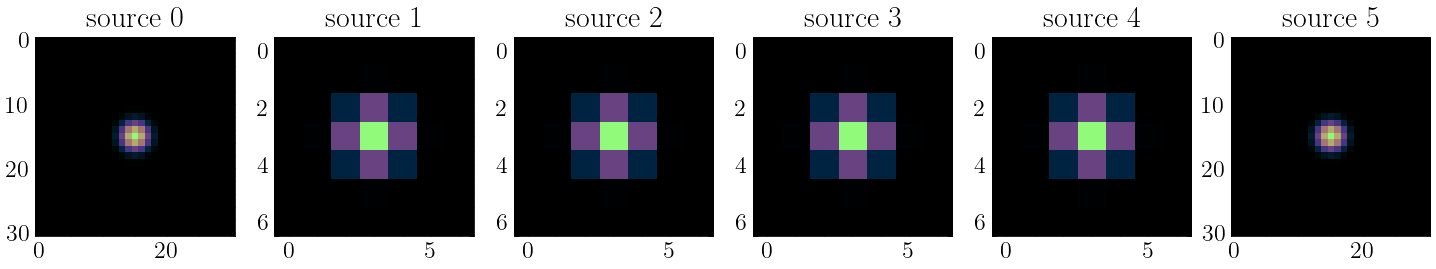

<Figure size 600x450 with 0 Axes>

In [11]:
import cmasher as cmr
cmap = cmr.lilac
int_method='none'
fig, axes = plt.subplots(1, len( scene.sources ), figsize=(15,6),dpi=120)
for i, ax in enumerate(axes):
    if True:#i!=indtransient:
        y = scene.sources[i].morphology()#[0]
    else:
        y = scene.sources[i].morphology.data
    ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.set_title(f"source {i}", fontsize = 18)
    ax.invert_yaxis()
plt.show()
plt.clf()

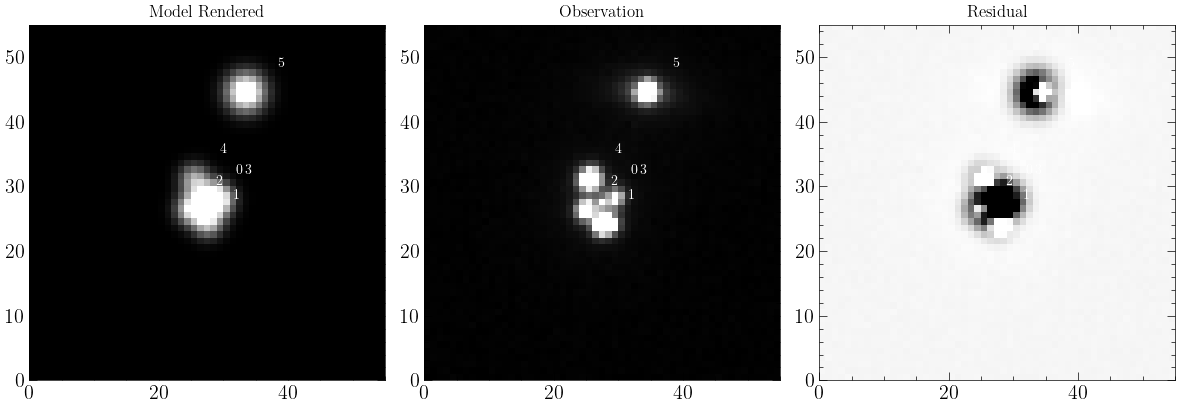

In [12]:
#print(obs_hsc.data.shape,obs_hst.data.shape)
#print(frameall.channels,channels_zeroed)
#print(obs_hsc.render(scene()).shape,obs_hst.render(scene()).shape)
scarlet2.plot.scene(
    scene,
    observation=observations_sc2[-1],
    norm=None,#normsingle[0],
    channel_map=None,
    show_model=False,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=False,
    linear=True,
)
plt.show()

In [13]:
scenes = []
#Fit the scene!
def scene_saver(scene, *args):
    scenes.append(scene)
scene_ = scene.fit(observations_sc2, parameters,max_iter=stepnum, e_rel=1e-8,callback=scene_saver)

flux = scene.sources[0].spectrum.data
print(flux)  
flux = scene.sources[1].spectrum.data
print(flux) 
flux = scene_.sources[0].spectrum.data
print(flux)  
flux = scene_.sources[1].spectrum.data
print(flux)  

100%|██████████| 3000/3000 [2:16:03<00:00,  2.72s/it, loss=14741157.00, max_change=0.000349]  

[13.992585 17.156294 13.46698   0.1       0.1       0.1     ]
[1.39925852e+01 1.71562939e+01 1.34669800e+01 1.35066204e+01
 1.33613815e+01 1.35300789e+01 1.35172892e+01 1.34824009e+01
 1.99022713e+01 1.33868752e+01 1.33503218e+01 1.93316269e+01
 1.33590317e+01 1.34447975e+01 1.68682270e+01 1.34527349e+01
 1.34807043e+01 1.33618116e+01 1.39570370e+01 1.89599915e+01
 2.67977543e+01 2.34383278e+01 3.93206062e+01 2.28150272e+01
 4.25308266e+01 2.28587742e+01 2.27767754e+01 2.88041973e+01
 2.26620579e+01 2.45345840e+01 2.27905521e+01 2.31783123e+01
 2.25020962e+01 2.27767525e+01 2.25710182e+01 3.42794189e+01
 2.28811436e+01 2.27354889e+01 3.67978363e+01 2.29932766e+01
 2.27467022e+01 1.86883907e+01 2.12742767e+01 3.32907410e+01
 2.93020935e+01 1.86486473e+01 1.88874073e+01 2.11595955e+01
 1.86090775e+01 1.96587067e+01 3.39105797e+01 1.86125336e+01
 1.87773151e+01 1.87334385e+01 2.61209126e+01 1.86334877e+01
 2.30522575e+01 1.87629471e+01 1.87025146e+01 1.85317993e+01
 9.99999997e-07 9.99999

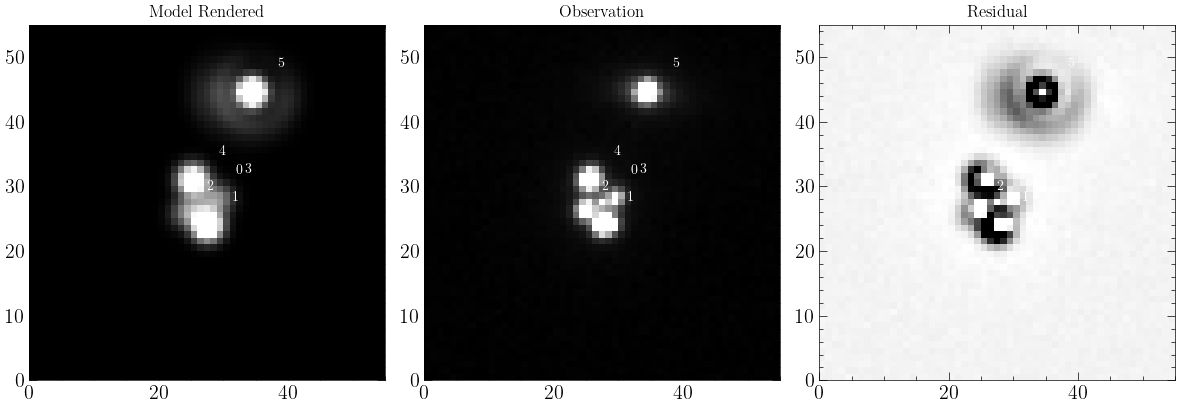

In [14]:
scarlet2.plot.scene(
    scene_,
    observation=observations_sc2[-1],
    norm=None,#normsingle[0],
    channel_map=None,
    show_model=False,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=False,
    linear=True,
)
plt.show()

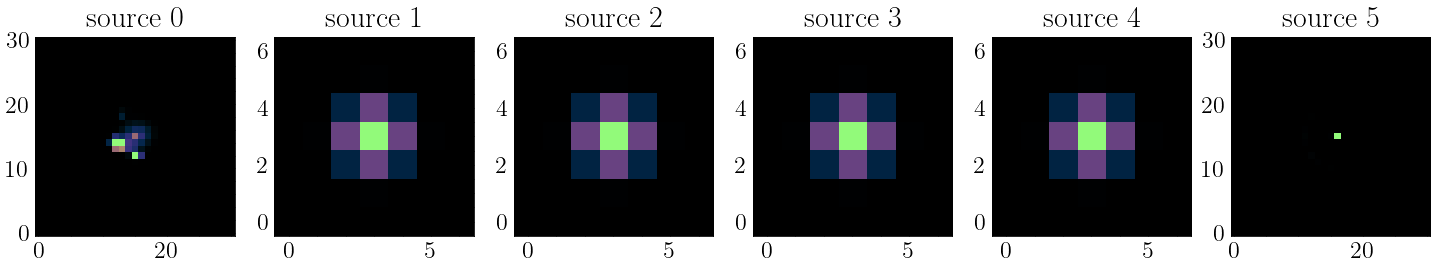

<Figure size 600x450 with 0 Axes>

In [15]:
import cmasher as cmr
cmap = cmr.lilac
int_method='none'
fig, axes = plt.subplots(1, len( scene.sources ), figsize=(15,6),dpi=120)
for i, ax in enumerate(axes):
    y = scene_.sources[i].morphology()
    #ax.imshow(np.log10(y), cmap = cmap,interpolation=int_method,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.set_title(f"source {i}", fontsize = 18)
    #ax.invert_yaxis()
plt.show()
plt.clf()

['g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g'
 'g' 'g' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r'
 'r' 'r' 'r' 'r' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i'
 'i' 'i' 'i' 'i' 'i' 'i'] [0.12496278 0.11916172 0.12884174 0.12681966 0.12311234 0.12167428
 0.1304394  0.12047127 0.12002362 0.13331759 0.12886564 0.11696541
 0.13324596 0.12823971 0.11664133 0.12331633 0.12475396 0.12558027
 0.11039557 0.1120696  0.11456297 0.10664707 0.10289319 0.1072981
 0.10621674 0.12102848 0.11068503 0.110378   0.10707823 0.10469084
 0.11577096 0.11056978 0.10853616 0.1083648  0.10558478 0.10534667
 0.10363521 0.11318891 0.09942777 0.12180766 0.11330289 0.1060811
 0.09746139 0.10028531 0.11199526 0.09930132 0.09863271 0.10877967
 0.09653068 0.09717881 0.10357407 0.09859977 0.09940509 0.09710562
 0.09900982 0.10202169 0.10497605 0.09426583 0.10621474 0.10274286]
[23.357859 22.305315 22.546732 23.051434 21.8344   22.097488 21.442816
 21.443684 21.0

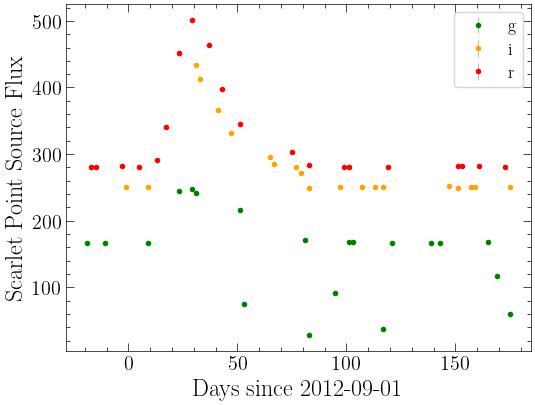

[25.712275 23.936224 24.462036 25.48879  23.827026 24.248024 21.517197
 21.518557 21.33961  21.522833 21.517838 21.338388 21.523022 21.51883
 21.450895 21.51994  21.526278 21.516432 21.486248 21.40719 ] [array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])] [0.41438156 0.07697258 0.13507688 0.34230433 0.07191535 0.10474144
 0.00907815 0.00839491 0.00709285 0.00932676 0.00897392 0.00690435
 0.00932337 0.00893848 0.00763696 0.00860412 0.00875538 0.00873382
 0.00746726 0.00704813]
Saved /scratch/gpfs/cw1074/SNsims_TD_noise/image_LSST_8771/8771_2g_lightcurve.txt
[20.98629  21.0909

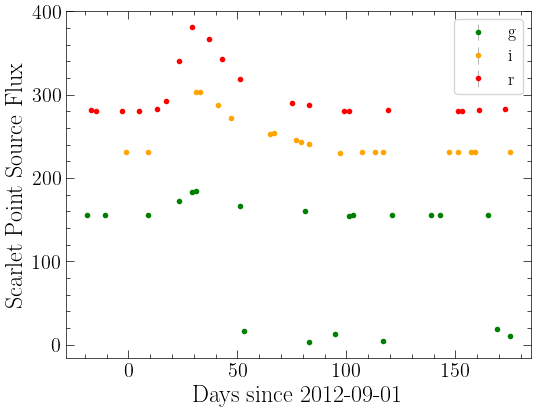

[27.743023 23.794998 25.10447  26.001987 23.115267 23.769367 29.213392
 29.205399 24.2756   29.264578 29.260935 24.564396 29.265633 29.228222
 27.760174 29.237827 29.286581 29.280785 28.888414 27.113354] [array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])] [0.06758437 0.24409227 0.54915016 0.03733518 0.06739935 0.10597817
 0.13474902]


ValueError: 'yerr' (shape: (7,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (20,))

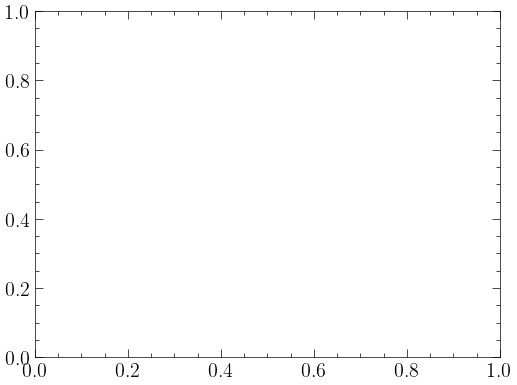

In [27]:
times=np.asfarray(times)
srcname=str(imgindex)
epochs = np.asarray([c[0] for c in channels_all])[:-6]

bgarr=np.copy(np.asarray(bgarrall))[:-6]
print(epochs,bgarr)
for indtransient in range(1,5):
    flux = np.copy(scene_.sources[indtransient].spectrum.data[:-6] * np.sum(scene_.sources[indtransient].morphology(),axis=(-2,-1))) 
    
    times=np.asfarray(times)
    timesz = ['2012-09-01T00:00:00']
    t = Time(timesz, format='isot', scale='utc')
    now = t[0]
    
    for bind,(b,c,background) in enumerate(zip(['g','i','r'],['green','orange','red'],bgarr)):
        mags = 27-2.5*np.log10(flux[epochs==b])
        print(mags,[epochs==b],1.0857*bgarr[epochs==b][mags<27]*10/flux[epochs==b][mags<27])
        plt.errorbar(times[epochs==b]-now.mjd,flux[epochs==b],yerr = bgarr[epochs==b][mags<27]/flux[epochs==b][mags<27],label=b,color=c,marker='.',linestyle=' ',ecolor='grey',elinewidth=0.4,capthick=0.4)
        out = np.column_stack((times[epochs==b],flux[epochs==b],bgarr[epochs==b]))
        np.savetxt(plotdir+'/'+srcname+'_'+str(indtransient)+b+'_lightcurve.txt',out)     
        print('Saved',plotdir+'/'+srcname+'_'+str(indtransient)+b+'_lightcurve.txt')
    plt.xlabel('Days since 2012-09-01')
    #plt.gca().invert_yaxis()
    #plt.ylim((22,17))
    #plt.xlim((500,850))
    plt.ylabel('Scarlet Point Source Flux')#Magnitude')
    plt.legend(frameon=True)
    
    
    plt.savefig(plotdir+'/'+srcname+'_'+str(indtransient)+'_lightcurve.pdf')
    print('Saved',plotdir+'/'+srcname+'_'+str(indtransient)+'_lightcurve.pdf')
    plt.show()
    plt.clf()

ani = plot.scene(scenes, observations[-], show_model=True, show_rendered=True, show_observed=True, show_residual=True)
ani.save("test_multires_withnoise_partialprior_starlet.mp4", writer="ffmpeg")

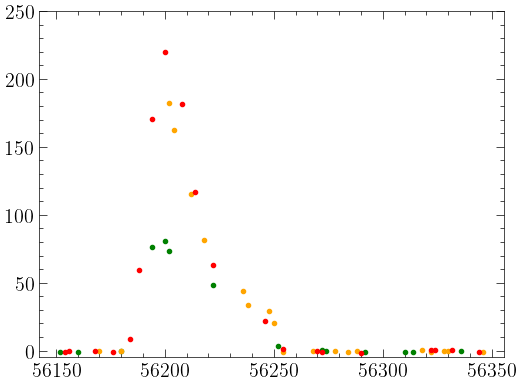

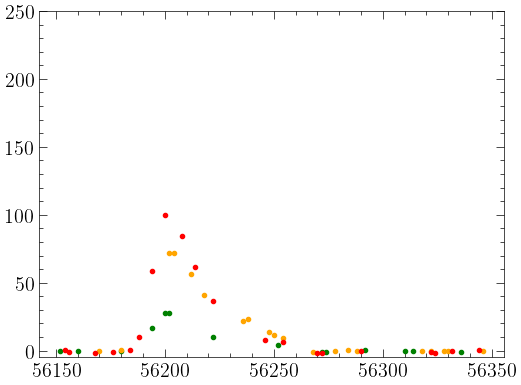

FileNotFoundError: /scratch/gpfs/cw1074/SNsims_TD_noise/image_LSST_8771/8771_3g_lightcurve.txt not found.

In [20]:
import numpy as np
data_path = '/scratch/gpfs/cw1074/SNsims_TD_noise'
imgindex=8771#1568
plotdir=data_path+'/'+"image_LSST_"+str(imgindex)
for indtransient in range(1,5):
    for bind,(b,c,background) in enumerate(zip(['g','i','r'],['green','orange','red'],bgarr)):
        srcname=str(imgindex)
        out = np.loadtxt(plotdir+'/'+srcname+'_'+str(indtransient)+b+'_lightcurve.txt')
        
        plt.errorbar(out[:,0],out[:,1]-np.median(out[-10:,1]),yerr = out[:,2],label=b,color=c,marker='.',linestyle=' ',ecolor='grey',elinewidth=0.4,capthick=0.4)
    plt.ylim((-5,250))
    plt.show()
       
        